In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data
df = pd.read_csv("/content/sample_data/Placement.csv")

df.head()
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Student_ID        1000 non-null   int64  
 1   CGPA              1000 non-null   float64
 2   Internships       1000 non-null   int64  
 3   Placed            1000 non-null   object 
 4   Salary (INR LPA)  1000 non-null   float64
dtypes: float64(2), int64(2), object(1)
memory usage: 39.2+ KB


,Student_ID,CGPA,Internships,Salary (INR LPA)
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,7.515560,2.045000,11.795580
std,288.819436,0.783422,1.424431,10.105559
min,1.000000,4.910000,0.000000,0.000000
25%,250.750000,6.980000,1.000000,0.000000
50%,500.500000,7.520000,2.000000,11.715000
75%,750.250000,8.020000,3.000000,20.935000
max,1000.000000,10.580000,4.000000,29.900000


In [32]:
# Drop rows with missing Salary
df = df.dropna(subset=["Salary (INR LPA)"])

# Choose target and initial features
target_col = "Salary (INR LPA)"
feature_cols = ["Student_ID","CGPA", "Internships","Placed"]

X = df[feature_cols].copy()
y = df[target_col].copy()


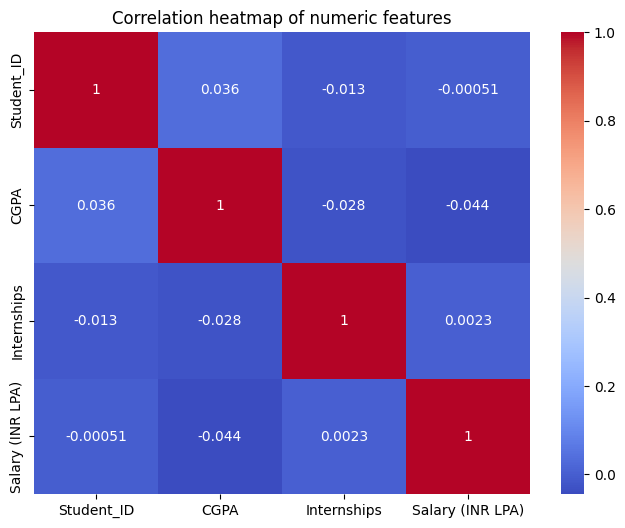

In [33]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation heatmap of numeric features")
plt.show()


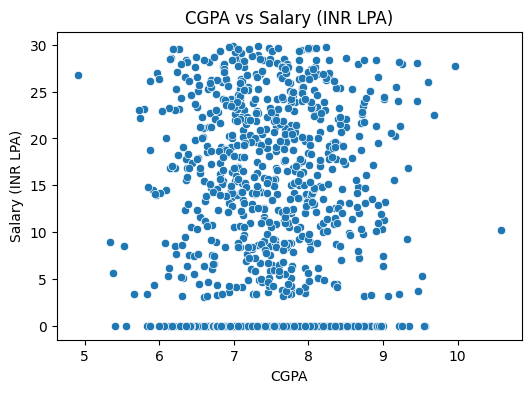

In [34]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="CGPA", y="Salary (INR LPA)")
plt.title("CGPA vs Salary (INR LPA)")
plt.show()


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_features = ["CGPA", "Internships"]
categorical_features = ["Placed"]

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop="first", handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [36]:
# Linear, Decision Tree, Random Forest

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

linreg = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])

linreg.fit(X_train, y_train)

y_train_pred_lr = linreg.predict(X_train)
y_test_pred_lr = linreg.predict(X_test)

mse_train_lr = mean_squared_error(y_train, y_train_pred_lr)
mse_test_lr = mean_squared_error(y_test, y_test_pred_lr)
r2_train_lr = r2_score(y_train, y_train_pred_lr)
r2_test_lr = r2_score(y_test, y_test_pred_lr)

mse_train_lr, mse_test_lr, r2_train_lr, r2_test_lr

(40.20253887219661, 36.71146534484024, 0.6071363858079553, 0.6356035241296791)

In [37]:
# Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor

dt = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42, max_depth=5))
])

dt.fit(X_train, y_train)

y_train_pred_dt = dt.predict(X_train)
y_test_pred_dt = dt.predict(X_test)

mse_train_dt = mean_squared_error(y_train, y_train_pred_dt)
mse_test_dt = mean_squared_error(y_test, y_test_pred_dt)
r2_train_dt = r2_score(y_train, y_train_pred_dt)
r2_test_dt = r2_score(y_test, y_test_pred_dt)

mse_train_dt, mse_test_dt, r2_train_dt, r2_test_dt


(36.46819973106312, 38.905813824430865, 0.6436287570054153, 0.6138225125224537)

In [38]:
# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

rf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100, random_state=42, max_depth=7
    ))
])

rf.fit(X_train, y_train)

y_train_pred_rf = rf.predict(X_train)
y_test_pred_rf = rf.predict(X_test)

mse_train_rf = mean_squared_error(y_train, y_train_pred_rf)
mse_test_rf = mean_squared_error(y_test, y_test_pred_rf)
r2_train_rf = r2_score(y_train, y_train_pred_rf)
r2_test_rf = r2_score(y_test, y_test_pred_rf)

mse_train_rf, mse_test_rf, r2_train_rf, r2_test_rf

(31.227509518105354,
 40.225322507876825,
 0.6948413559029281,
 0.6007251242920606)

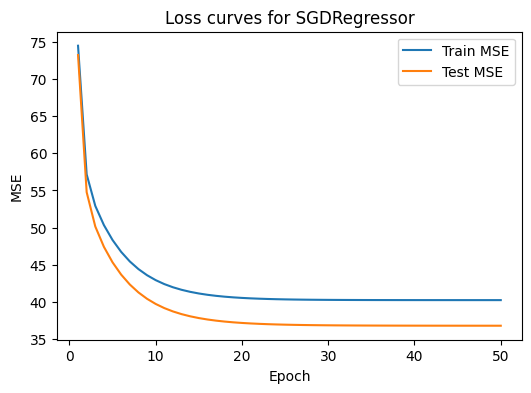

In [41]:
# Loss curves and regression line plot
import warnings
from sklearn.linear_model import SGDRegressor
from sklearn.exceptions import ConvergenceWarning

# Solving warning messages from my codes
warnings.filterwarnings("ignore", category=ConvergenceWarning)

sgd_reg = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", SGDRegressor(max_iter=1, warm_start=True, penalty=None, learning_rate="constant", eta0=0.001, random_state=42))
])

train_losses = []
test_losses = []

for epoch in range(1, 51):
    sgd_reg.fit(X_train, y_train)
    y_train_pred = sgd_reg.predict(X_train)
    y_test_pred = sgd_reg.predict(X_test)

    train_losses.append(mean_squared_error(y_train, y_train_pred))
    test_losses.append(mean_squared_error(y_test, y_test_pred))

plt.figure(figsize=(6, 4))
plt.plot(range(1, 51), train_losses, label="Train MSE")
plt.plot(range(1, 51), test_losses, label="Test MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Loss curves for SGDRegressor")
plt.legend()
plt.show()

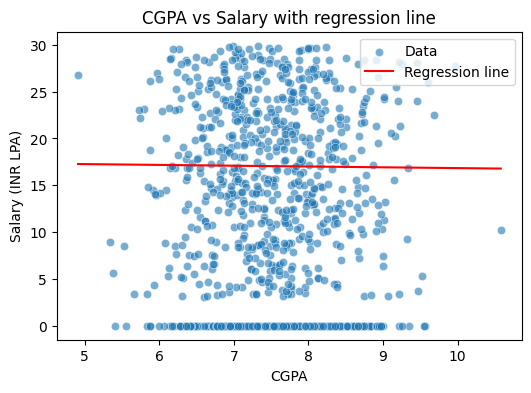

In [45]:
# Use linear model predictions for visualization
cgpa_range = np.linspace(df["CGPA"].min(), df["CGPA"].max(), 100)
viz_df = pd.DataFrame({
    "CGPA": cgpa_range,
    "Internships": df["Internships"].median(),
    "Placed": df["Placed"].mode()[0]
})

salary_pred_line = linreg.predict(viz_df)

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="CGPA", y="Salary (INR LPA)", alpha=0.6, label="Data")
plt.plot(cgpa_range, salary_pred_line, color="red", label="Regression line")
plt.xlabel("CGPA")
plt.ylabel("Salary (INR LPA)")
plt.title("CGPA vs Salary with regression line")
plt.legend()
plt.show()


In [46]:
# Select best model and save it
import joblib

best_model = rf

joblib.dump(best_model, "best_salary_model.joblib")

['best_salary_model.joblib']

In [49]:
# pick one row from test set
one_student = X_test.iloc[[0]]
true_salary = y_test.iloc[0]

loaded_model = joblib.load("best_salary_model.joblib")
pred_salary = loaded_model.predict(one_student)

print("Features:", one_student)
print("True salary:", true_salary)
print("Predicted salary:", pred_salary[0])


Features:      Student_ID  CGPA  Internships Placed
521         522  7.93            1    Yes
True salary: 25.49
Predicted salary: 17.32974801882527
